1. What is the approximate depth of a decision tree trained (without restrictions) on a training set with one million instances?

A: log2(1e6)

2. Is a node’s Gini impurity generally lower or higher than its parent’s? Is it generally lower/higher, or always lower/higher?

A: The gini impurity is a measure of how pure the node is (ie. how close to having only one class it is). The gini impurity is generally lower in child nodes, but not always as the CART algorithm minimizes the weighted sum of a node's children's impurities and so a node can end up having a higher impurity than it's parent, but a lower weight due to less samples.

3. If a decision tree is overfitting the training set, is it a good idea to try decreasing max_depth?

A: Yes, decreasing the max_depth will force the tree to only pick the highest impact sample splits and thus help avoid overfitting.

4. If a decision tree is underfitting the training set, is it a good idea to try scaling the input features?

A: Scaling has no impact on decision trees so, no it wouldn't matter.

5. If it takes one hour to train a decision tree on a training set containing one million instances, roughly how much time will it take to train another decision tree on a training set containing ten million instances? Hint: consider the CART algorithm’s computational complexity.

A: The computational complexity of the CART algorithm is O(n\*m*log2(m)) so it would take roughly 30 times as long (10\*log2(10)), so 30 hours.

6. If it takes one hour to train a decision tree on a given training set, roughly how much time will it take if you double the number of features?

A: It will take twice as long as the algorithm will have to evaluate twice the features to split on during each step.

7. Train and fine-tune a decision tree for the moons dataset by following these steps:

    1. Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset.

    2. Use train_test_split() to split the dataset into a training set and a test set.

    3. Use grid search with cross-validation (with the help of the GridSearchCV class) to find good hyperparameter values for a DecisionTreeClassifier. Hint: try various values for max_leaf_nodes.

    4. Train it on the full training set using these hyperparameters, and measure your model’s performance on the test set. You should get roughly 85% to 87% accuracy.

In [1]:
from sklearn.datasets import make_moons
moons = make_moons(n_samples=int(1e5), noise=0.4)
moons_X = moons[0]
moons_y = moons[1]

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(moons_X, moons_y, train_size=0.80, random_state=42)
print(X_train.shape, y_train.shape)

(80000, 2) (80000,)


In [3]:
from sklearn.tree import DecisionTreeClassifier
dtclf = DecisionTreeClassifier(random_state=42)

In [4]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_leaf_nodes': [4, 8, 16],
    'max_depth': [3, 6]
}
grid_search = GridSearchCV(estimator=dtclf, param_grid=param_grid, scoring='accuracy')

In [5]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': 6, 'max_leaf_nodes': 16}


In [6]:
print("Train accuracy:", best_model.score(X_train, y_train))
print("Test accuracy:", best_model.score(X_test, y_test))

Train accuracy: 0.8571875
Test accuracy: 0.86205


8. Grow a forest by following these steps:

    1. Continuing the previous exercise, generate 1,000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use Scikit-Learn’s ShuffleSplit class for this.

    2. Train one decision tree on each subset, using the best hyperparameter values found in the previous exercise. Evaluate these 1,000 decision trees on the test set. Since they were trained on smaller sets, these decision trees will likely perform worse than the first decision tree, achieving only about 80% accuracy.

    3. Now comes the magic. For each test set instance, generate the predictions of the 1,000 decision trees, and keep only the most frequent prediction (you can use SciPy’s mode() function for this). This approach gives you majority-vote predictions over the test set.

    4. Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a random forest classifier!

In [7]:
from sklearn.model_selection import ShuffleSplit
rs = ShuffleSplit(n_splits=int(1e3), train_size=100, test_size=None, random_state=42)

In [9]:
trees = []
for (train_index, _) in rs.split(X_train):
    dt = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=16)
    dt.fit(X_train[train_index], y_train[train_index])
    trees.append(dt)

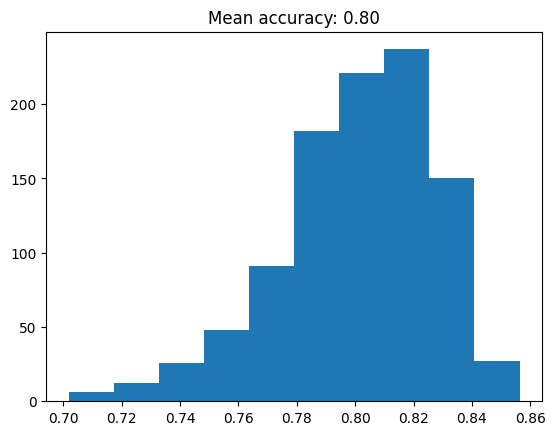

In [14]:
import matplotlib.pyplot as plt
import numpy as np
accuracies = []
for tree in trees:
    accuracies.append(tree.score(X_test, y_test))
plt.hist(accuracies)
plt.title(f"Mean accuracy: {np.mean(accuracies):.2f}")
plt.show()

In [26]:
from scipy.stats import mode
preds = []
for i, features in enumerate(X_test[:100]):
    voting = [tree.predict([features]) for tree in trees]
    majority = mode(voting).mode[0]
    preds.append(majority)

In [27]:
print(f"Accuracy: {np.mean(preds == y_test[:100])}")

Accuracy: 0.89
